<a href="https://colab.research.google.com/github/Danial9218/Python-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%962__%D0%90%D0%BF%D1%80%D0%BE%D0%BA%D1%81%D0%B8%D0%BC%D0%B0%D1%86%D0%B8%D1%8F_%D0%BD%D0%B5%D0%BB%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D1%8B%D1%85_%D1%84%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D0%B9_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №2 "Апроксимация нелинейных функций"

Выполнил: Леденёв Данил Дмитриевич ИТ-24Д

**Цель работы:** изучить построение полносвязных нейронных сетей для аппроксимации скалярной нелинейной функции и сравнить обычную последовательную архитектуру с ветвящейся сетью.

## Лабораторная работа №2. Часть 1

In [2]:
# Установка дополнительных пакетов
!pip install torchsummary torchinfo torchview

In [3]:
# Базовые библиотеки
import math
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torchinfo import summary as info_summary
from torchview import draw_graph

# Устройство вычислений (CPU / GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)

# (опционально) инструменты для вывода архитектуры
try:
    from torchsummary import summary
except ImportError:
    summary = None

Используемое устройство: cuda


In [4]:
# Вариант 21: Y = 2cot(X)
# cot(X) имеет вертикальные асимптоты при X = k*pi.
t0 = np.arange(0.05, 0.95, 0.001, dtype=np.float32)
t  = 2 * math.pi * t0

# убираем точки, где sin(t) близок к 0 (разрывы котангенса)
valid_mask = np.abs(np.sin(t)) > 0.2
t0 = t0[valid_mask]
t  = t[valid_mask]

# Целевая функция: 2 * cot(X) = 2 / tan(X)
x  = (2.0 / np.tan(t)).astype(np.float32)

X = torch.from_numpy(t0.reshape(-1, 1)).to(device)
y = torch.from_numpy(x.reshape(-1, 1)).to(device)

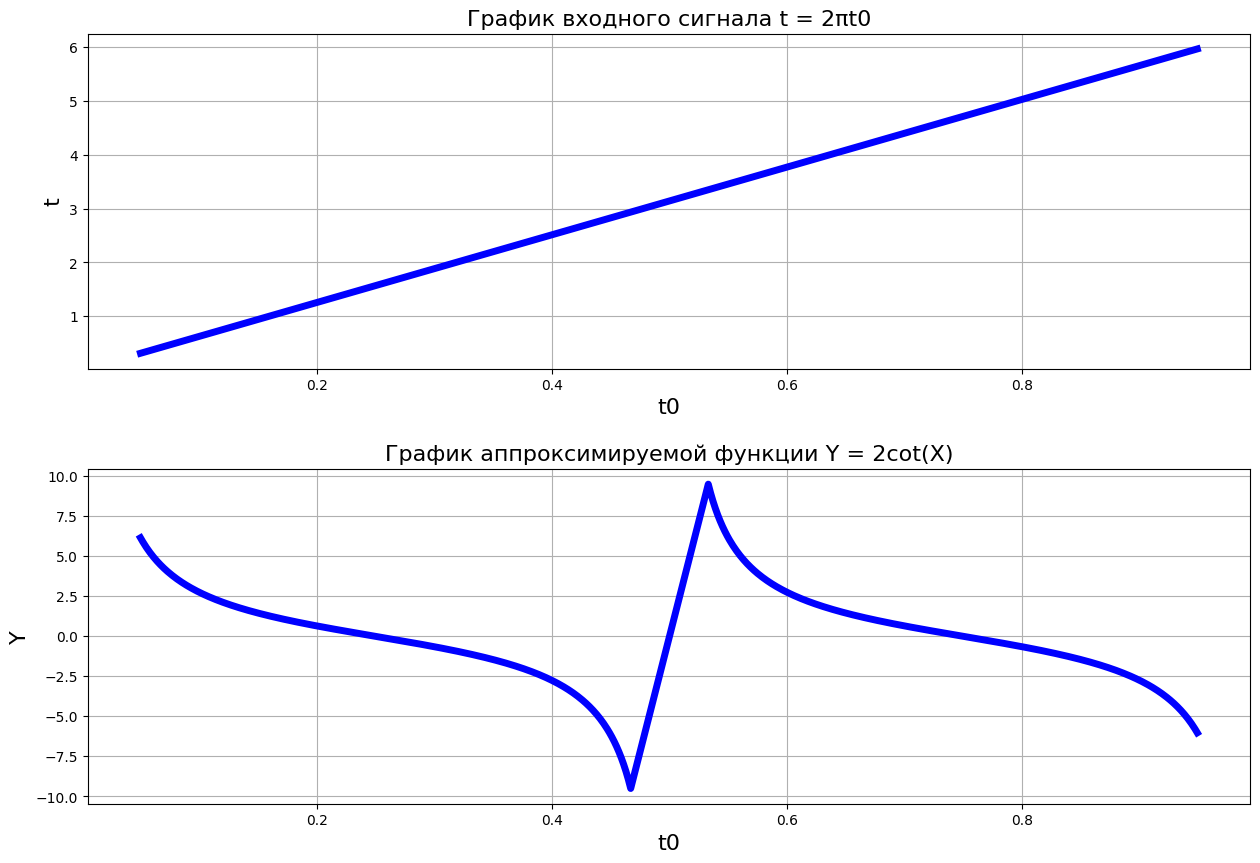

In [5]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(t0, t, "b", linewidth=5)
plt.title("График входного сигнала t = 2πt0", fontsize=16)
plt.ylabel("t", fontsize=16)
plt.xlabel("t0", fontsize=16)
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t0, x, "b", linewidth=5)
plt.title("График аппроксимируемой функции Y = 2cot(X)", fontsize=16)
plt.ylabel("Y", fontsize=16)
plt.xlabel("t0", fontsize=16)
plt.grid()

plt.subplots_adjust(wspace=0, hspace=0.3)
plt.show()

In [6]:
# Модель полносвязной сети для аппроксимации функции
class NNSin(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        # два скрытых слоя по 50 нейронов
        self.fc1 = nn.Linear(in_features, 50)
        self.fc2 = nn.Linear(50, 50)
        # выходной слой: одно значение функции
        self.fc3 = nn.Linear(50, 1)
        self.act = nn.Tanh()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)            # для регрессии выход обычно без активации
        return x




model_sin = NNSin(in_features=1).to(device)

print("=== Структура модели NNSin (torchinfo) ===")
info_summary(model_sin, input_size=(32, 1))

=== Структура модели NNSin (torchinfo) ===


Layer (type:depth-idx)                   Output Shape              Param #
NNSin                                    [32, 1]                   --
├─Linear: 1-1                            [32, 50]                  100
├─Tanh: 1-2                              [32, 50]                  --
├─Linear: 1-3                            [32, 50]                  2,550
├─Tanh: 1-4                              [32, 50]                  --
├─Linear: 1-5                            [32, 1]                   51
Total params: 2,701
Trainable params: 2,701
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.09
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.01
Estimated Total Size (MB): 0.04

=== Структура модели NNSin (torchsummary) ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 50]             100
              Tanh-2                   [-1, 50]               0
            Linear-3                   [-1, 50]           2,550
              Tanh-4                   [-1, 50]               0
            Linear-5                    [-1, 1]              51
Total params: 2,701
Trainable params: 2,701
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------

=== Структура модели (torchinfo) ===

=== Структура модели (torchview) ===


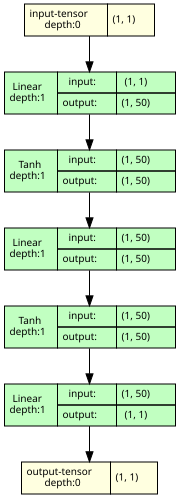

In [7]:
print("=== Структура модели NNSin (torchsummary) ===")
summary(model_sin, input_size=(1,))

print("\n=== Структура модели (torchinfo) ===")
info_summary(model_sin, input_size=(32, 1))  # batch_size=32, 1 признак

print("\n=== Структура модели (torchview) ===")
graph = draw_graph(
    model_sin,
    input_size=(1, 1),   # (batch_size, число признаков)
    device=device,
    expand_nested=True
)
graph.visual_graph

In [8]:
import math
import numpy as np
import torch

# Создание обучающей выборки
X_train_min = 0.3
X_train_max = 2.8
t0 = np.arange(X_train_min, X_train_max, 0.01, dtype=np.float32)

# Y = 2cot(X) = 2 * cos(X) / sin(X)
x = 2 * np.cos(t0) / np.sin(t0)
x = x.astype(np.float32)

# Преобразуем в тензоры PyTorch
X_train = torch.from_numpy(t0.reshape(-1, 1)).to(device)
y_train = torch.from_numpy(x.reshape(-1, 1)).to(device)

print(f"Обучающая выборка: X ∈ [{X_train_min}, {X_train_max}], размер: {len(t0)}")
print(f"Диапазон Y: [{x.min():.3f}, {x.max():.3f}]")




# Параметры обучения
n_epochs   = 200         # число проходов по всему набору данных
batch_size = 32          # размер мини‑батча
criterion  = nn.MSELoss()              # функция потерь (MSE)
optimizer  = optim.Adam(model_sin.parameters(), lr=0.003)  # оптимизатор Adam

history = []  # здесь будем накапливать значение ошибки на каждой эпохе

for epoch in range(n_epochs):
    model_sin.train()                    # переводим модель в режим обучения
    permutation = torch.randperm(X_train.size(0))  # случайное перемешивание индексов

    epoch_loss = 0.0
    # цикл по мини‑батчам
    for i in range(0, X_train.size(0), batch_size):
        idx = permutation[i:i + batch_size]  # выбираем индексы текущего батча
        batch_x = X_train[idx]              # входы батча
        batch_y = y_train[idx]              # целевые значения батча

        optimizer.zero_grad()               # обнуляем градиенты
        y_pred = model_sin(batch_x)         # прямое распространение (forward)
        loss = criterion(y_pred, batch_y)   # вычисляем значение функции потерь
        loss.backward()                     # обратное распространение (backward)
        optimizer.step()                    # делаем шаг градиентного спуска

        epoch_loss += loss.item()           # аккумулируем ошибку по батчам

    history.append(epoch_loss)              # сохраняем суммарную ошибку за эпоху
    if (epoch + 1) % 40 == 0:               # периодический вывод прогресса
        print(f"Epoch {epoch+1:3d}/{n_epochs}, loss = {epoch_loss:.6f}")

Обучающая выборка: X ∈ [0.3, 2.8], размер: 250
Диапазон Y: [-5.452, 6.465]
Epoch  40/200, loss = 0.422446
Epoch  80/200, loss = 0.160326
Epoch 120/200, loss = 0.066961
Epoch 160/200, loss = 0.036937
Epoch 200/200, loss = 0.033101


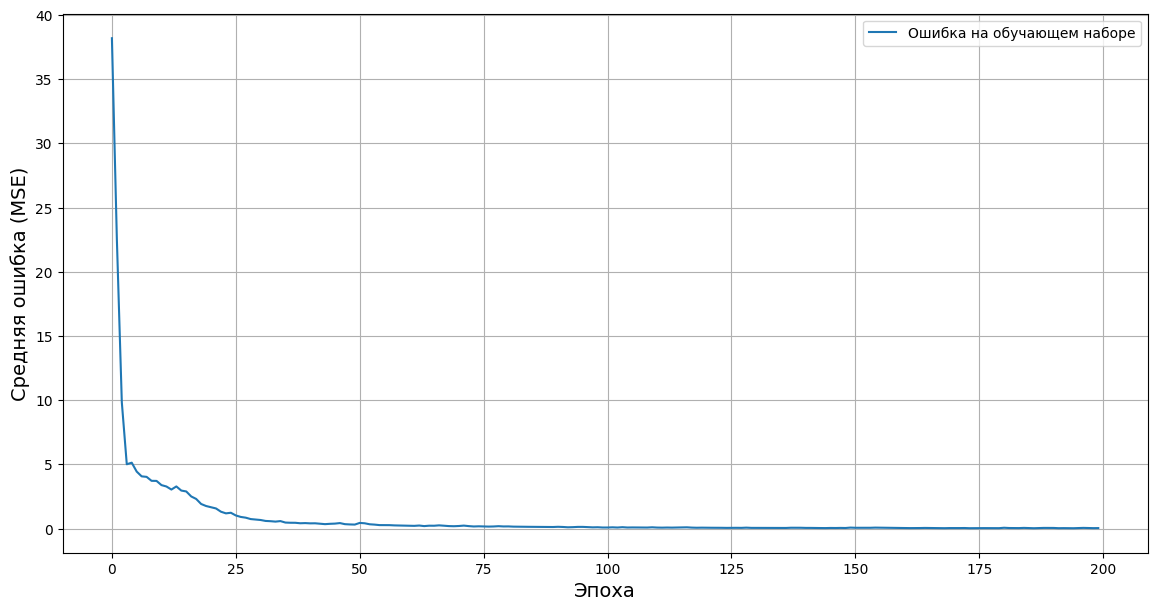

In [9]:
# Вывод графика процесса обучения
plt.figure(figsize=(14, 7))
plt.plot(history, label='Ошибка на обучающем наборе')
plt.ylabel('Средняя ошибка (MSE)', fontsize=14)
plt.xlabel('Эпоха', fontsize=14)
plt.grid()
plt.legend()
plt.show()

In [10]:
# Моделирование работы НС (получение предсказаний на обучающей выборке)
model_sin.eval()  # режим оценки (выключает dropout, batchnorm и т.п.)
with torch.no_grad():
    # X_train уже содержит t0 в виде тензора (N, 1)
    pred_train_tensor = model_sin(X_train)
    pred_train = pred_train_tensor.cpu().numpy().ravel()  # в NumPy для графика

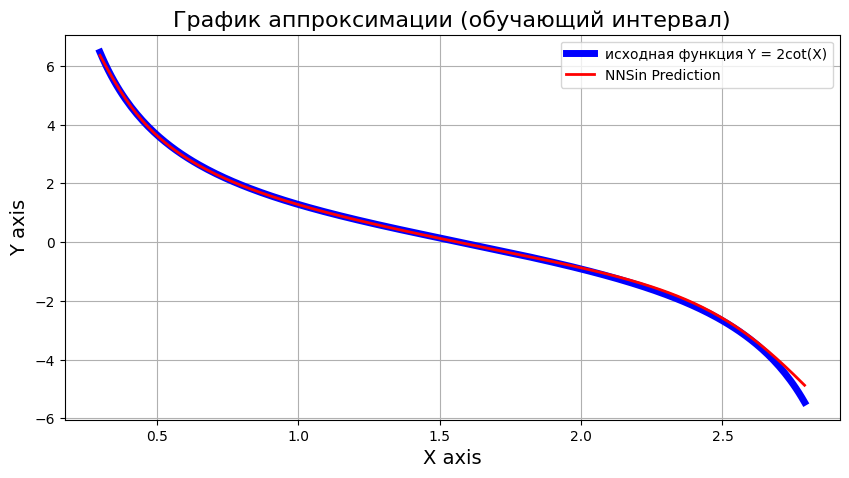

In [11]:
# Вывод графиков с результатом моделирования
plt.figure(figsize=(10, 5))
plt.plot(t0, x, 'b', linewidth=5, label='исходная функция Y = 2cot(X)')
plt.plot(t0, pred_train, 'r', linewidth=2, label='NNSin Prediction')
plt.title("График аппроксимации (обучающий интервал)", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend(loc="upper right")
plt.show()

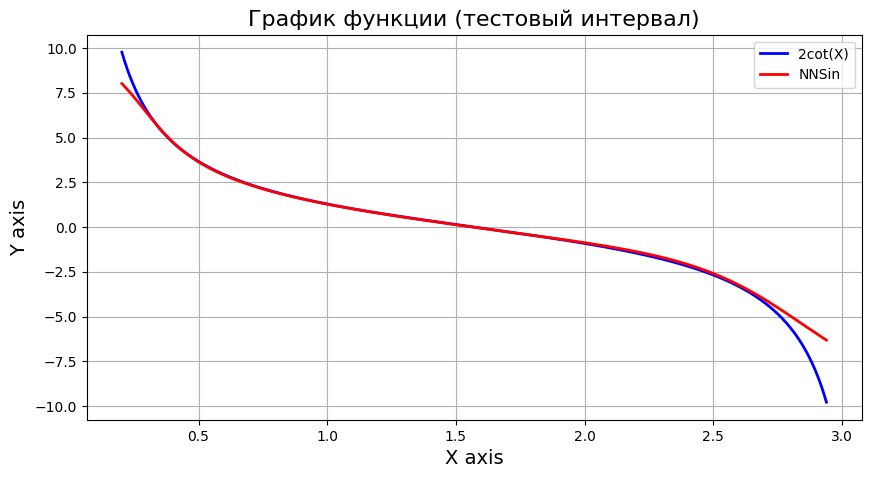

 MSE на обучающей выборке: 0.007984
 MSE на тестовой выборке:  0.216628


In [24]:
# Тестирование на данных, не входящих в обучающую выборку:
# Вариант 21: Y = 2cot(X)
# Берем интервал, который не включает точки разрыва, например [0.1, 3.0]
t0_test_full = np.arange(0.1, 3.0, 0.001, dtype=np.float32)


epsilon = 0.2
valid_mask = np.abs(np.sin(t0_test_full)) > epsilon
t0_test_clean = t0_test_full[valid_mask]


x_test_clean = (2.0 / np.tan(t0_test_clean)).astype(np.float32)

X_test_clean = torch.from_numpy(t0_test_clean.reshape(-1, 1)).to(device)

model_sin.eval()
with torch.no_grad():
    y_test_pred_clean = model_sin(X_test_clean).cpu().numpy().ravel()

plt.figure(figsize=(10, 5))

plt.plot(t0_test_clean, x_test_clean, 'b', label='2cot(X)', linewidth=2)
plt.plot(t0_test_clean, y_test_pred_clean, 'r', label='NNSin', linewidth=2)
plt.title("График функции (тестовый интервал)", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend()
plt.show()


mse_train = np.mean((pred_train - x)**2)
mse_test  = np.mean((y_test_pred_clean - x_test_clean)**2)
print(f" MSE на обучающей выборке: {mse_train:.6f}")
print(f" MSE на тестовой выборке:  {mse_test:.6f}")

## Лабораторная работа №2. Часть 2

## Теоретические сведения
### Ветвящиеся архитектуры

Для решения более сложных задач простой последовательной цепочки слоёв может быть недостаточно. Иногда сети необходимо выделить общую скрытую репрезентацию входа, а затем обработать её параллельно, чтобы извлечь независимые группы признаков.

Ветвящаяся архитектура строится следующим образом:
1. **Общая часть (Shared part):** Входные данные проходят через один или несколько общих слоёв.
2. **Ветви (Branches):** Выход общей части подаётся одновременно на входы нескольких независимых слоёв (веток). Каждая ветвь обучается выделять «свои» специфические закономерности.
3. **Объединение (Merge):** Результаты вычислений из всех ветвей объединяются (чаще всего с помощью конкатенации тензоров по признаковому измерению).
4. **Выходной слой:** Объединённый тензор подаётся на финальный слой для получения итогового предсказания.

В PyTorch такая логика реализуется напрямую внутри метода `forward()`: вы один раз пропускаете тензор через общие слои, сохраняете результат в промежуточную переменную, а затем подаёте эту переменную в каждую из ветвей. Результаты ветвей объединяются функцией `torch.cat`.

Одним из классических примеров ветвящейся архитектуры является Unet для задач сегментации изображений. В ней:

- **энкодер** (нисходящая часть) поэтапно уменьшает размер карты признаков, увеличивая число каналов и извлекая всё более абстрактные признаки;
- **декодер** (восходящая часть) восстанавливает пространственное разрешение с помощью операций upsampling / transposed‑conv;
- между соответствующими уровнями энкодера и декодера используются **skip‑соединения**: карты признаков из энкодера конкатенируются с картами декодера. Таким образом реализуются ветви, которые передают в декодер как высокоуровневые признаки, так и детальную пространственную информацию.

С точки зрения общей схемы, Unet как раз иллюстрирует идею *общей части + нескольких ветвей + объединения (concatenate)*, только в более сложном, многоуровневом варианте.

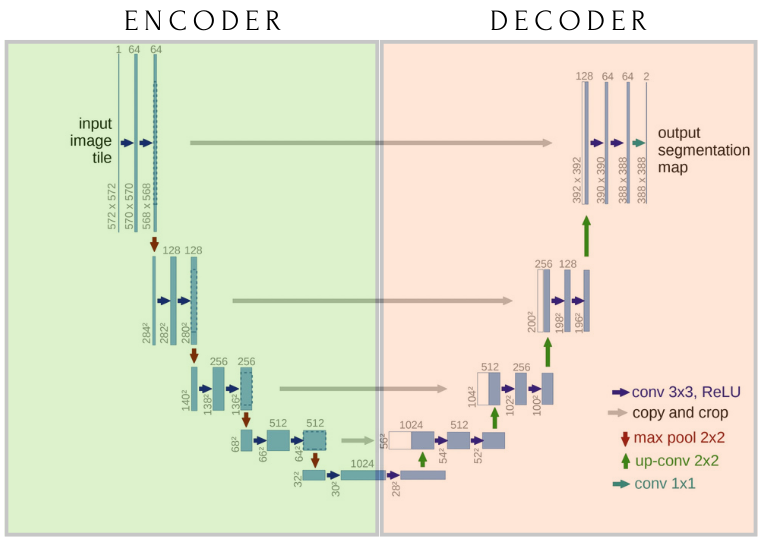

In [27]:
# Ветвящаяся модель для аппроксимации функции
class BranchSin(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        # основная ветка: два скрытых слоя по 50 нейронов с ReLU
        self.fc_main1 = nn.Linear(in_features, 50)
        self.fc_main2 = nn.Linear(50, 50)

        # параллельная ветка: один слой 50 нейронов с Sigmoid от исходного входа
        self.fc_branch1 = nn.Linear(in_features, 50)

        # выходной слой: после конкатенации 50 + 50 = 100 признаков
        self.fc_out = nn.Linear(100, 1)

        self.act_relu = nn.ReLU()
        self.act_sigmoid = nn.Sigmoid()

    def forward(self, x):
        # основная ветка
        x_main = self.act_relu(self.fc_main1(x))
        x_main = self.act_relu(self.fc_main2(x_main))

        # параллельная ветка
        x_branch = self.act_sigmoid(self.fc_branch1(x))

        # конкатенация двух ветвей по признаковому измерению
        x_concat = torch.cat([x_main, x_branch], dim=1)

        # выход без активации (регрессия)
        out = self.fc_out(x_concat)
        return out


=== Структура ветвящейся модели (torchview) ===


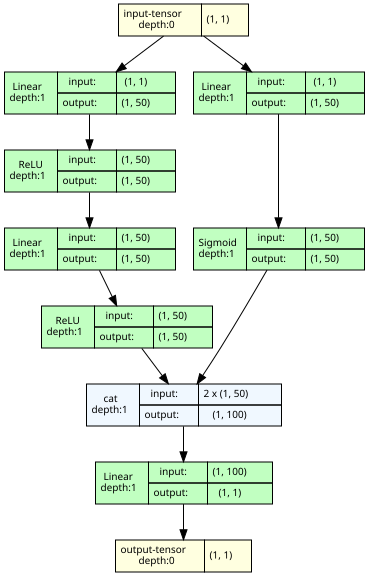

In [28]:
# Создание модели
model_branch = BranchSin(in_features=1).to(device)

print("\n=== Структура ветвящейся модели (torchview) ===")
graph_branch = draw_graph(
    model_branch,
    input_size=(1, 1),
    device=device,
    expand_nested=True
)
graph_branch.visual_graph

In [29]:
# Подготовка данных для PyTorch
X_train = torch.from_numpy(t0.reshape(-1, 1)).to(device)
y_train = torch.from_numpy(x.reshape(-1, 1)).to(device)

n_epochs   = 150         # увеличим для сложной функции
batch_size = 32
criterion  = nn.MSELoss()
optimizer_branch = optim.Adam(model_branch.parameters(), lr=0.005)  # уменьшим LR

history_branch = []

for epoch in range(n_epochs):
    model_branch.train()
    permutation = torch.randperm(X_train.size(0))

    epoch_loss = 0.0
    for i in range(0, X_train.size(0), batch_size):
        idx = permutation[i:i + batch_size]
        batch_x = X_train[idx]
        batch_y = y_train[idx]

        optimizer_branch.zero_grad()
        y_pred = model_branch(batch_x)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer_branch.step()

        epoch_loss += loss.item()

    history_branch.append(epoch_loss)
    if (epoch + 1) % 30 == 0:
        print(f"[Branch] Epoch {epoch+1:3d}/{n_epochs}, loss = {epoch_loss:.6f}")

[Branch] Epoch  30/150, loss = 0.687022
[Branch] Epoch  60/150, loss = 0.242913
[Branch] Epoch  90/150, loss = 0.069458
[Branch] Epoch 120/150, loss = 0.040224
[Branch] Epoch 150/150, loss = 0.040812


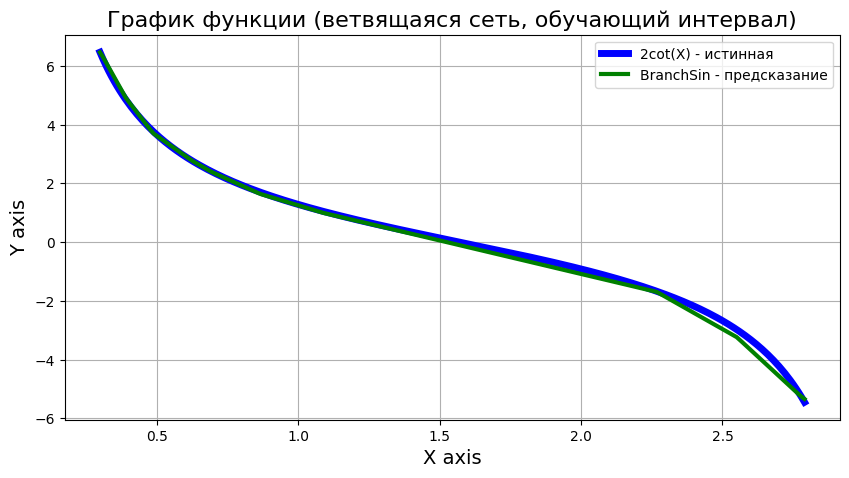

In [17]:
# Моделирование работы ветвящейся НС (обучающий интервал)
model_branch.eval()
with torch.no_grad():
    pred_branch_train_tensor = model_branch(X_train)
    pred_branch_train = pred_branch_train_tensor.cpu().numpy().ravel()

plt.figure(figsize=(10, 5))
plt.plot(t0, x, 'b', linewidth=5, label='2cot(X) - истинная')
plt.plot(t0, pred_branch_train, 'g', linewidth=3, label='BranchSin - предсказание')
plt.title("График функции (ветвящаяся сеть, обучающий интервал)", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend(loc="upper right")
plt.show()

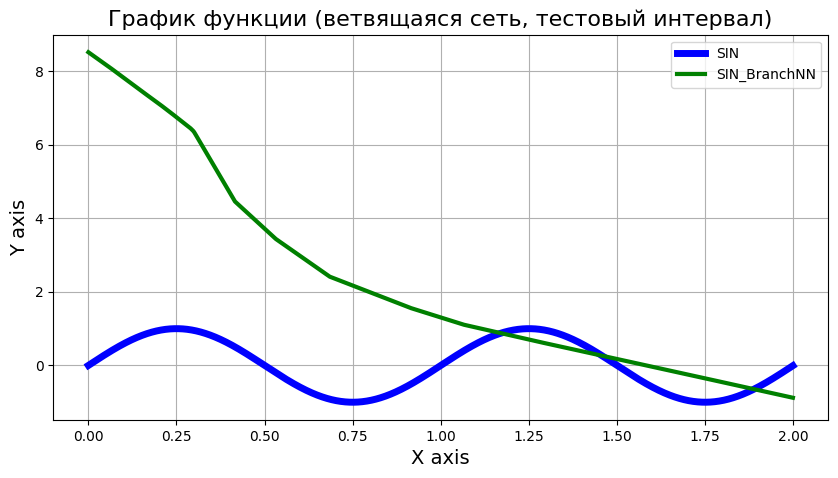

In [31]:
# Тестирование на данных, не входящих в обучающую выборку
t0_test = np.arange(0,2, 0.001, dtype=np.float32)
t_test  = 2 * math.pi * t0_test
x_test  = np.sin(t_test).astype(np.float32)

X_test = torch.from_numpy(t0_test.reshape(-1, 1)).to(device)

model_branch.eval()
with torch.no_grad():
    y_branch_test_tensor = model_branch(X_test)
    y_branch_test = y_branch_test_tensor.cpu().numpy().ravel()

plt.figure(figsize=(10, 5))
plt.plot(t0_test, x_test, 'b', label='SIN', linewidth=5)
plt.plot(t0_test, y_branch_test, 'g', label='SIN_BranchNN', linewidth=3)
plt.title("График функции (ветвящаяся сеть, тестовый интервал)", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend()
plt.show()

## Порядок выполнения работы

1. Студент выбирает номер варианта согласно списку группы.  
2. По номеру варианта выбирается целевая **нелинейная** функция \(Y=f(X)\) из таблицы вариантов.  
3. Сгенерировать обучающую выборку \((X, Y)\) на интервале, указанном преподавателем (например, \(X \in [0, 2\pi]\)), добавить тестовый интервал, не пересекающийся с обучающим.  
4. Реализовать в PyTorch две модели:
   - последовательную полносвязную сеть (NNSin);
   - ветвящуюся сеть (BranchSin) с двумя параллельными ветвями и последующей конкатенацией признаков.
5. Обучить обе сети на одной и той же выборке, подобрать гиперпараметры (число эпох, размер батча, скорость обучения) так, чтобы добиться разумной аппроксимации функции.
6. Сравнить качество:
   - по графикам на обучающем и тестовом интервале;
   - по числовым метрикам (MSE на обучающей и тестовой выборках);
   - по сложности модели (число параметров), форме графа сети (torchinfo / torchview).
7. Заполнить таблицу экспериментов, сделать краткие выводы о влиянии архитектуры (последовательная vs ветвящаяся) и гиперпараметров на качество аппроксимации.

### Таблица вариантов

| № варианта | Функция              | № варианта | Функция                    |
|-----------:|----------------------|-----------:|----------------------------|
| 1          | Y = 5sin(X+3)        | 26         | Y = 2sin(X) - 5            |
| 2          | Y = sin(X)           | 27         | Y = sin(X) + 6             |
| 3          | Y = cos(X)/sin(X)    | 28         | Y = cos(X)*3sin(X)         |
| 4          | Y = 4X^2 + 1         | 29         | Y = sin(X) + 10            |
| 5          | Y = cos(X)           | 30         | Y = 2cos(X)sin(X)          |
| 6          | Y = cos(X)/2         | 31         | Y = 15X^2 - 4              |
| 7          | Y = tan(X)           | 32         | Y = 3tan(X)                |
| 8          | Y = cot(X)           | 33         | Y = 2 + sin(X)             |
| 9          | Y = 2sin(X)          | 34         | Y = 2sin(X-6) - 5          |
| 10         | Y = X^2 + 5          | 35         | Y = X^2 - 6                |
| 11         | Y = cos(X)/sin(X)    | 36         | Y = cos(X)/(3sin(X))       |
| 12         | Y = sin(X) + 5       | 37         | Y = sin(X) - 2             |
| 13         | Y = cos(X)sin(X)     | 38         | Y = 2cos(X)                |
| 14         | Y = 15X^2            | 39         | Y = 5X^2 - 4               |
| 15         | Y = 2tan(X)          | 40         | Y = tan(X)/3               |
| 16         | Y = 1 + sin(X)       | 41         | Y = 2 + 3sin(X)            |
| 17         | Y = 4X^2 + 3         | 42         | Y = 2sin(X) + 3            |
| 18         | Y = cos(X)/10        | 43         | Y = 3X^2 + 6               |
| 19         | Y = cos(X)/6         | 44         | Y = cos(X)*4sin(X)         |
| 20         | Y = 4tan(X)          | 45         | Y = sin(X) - 5             |
| 21         | Y = 2cot(X)          | 46         | Y = 0.5cos(X)sin(X)        |
| 22         | Y = X^2 - 4          | 47         | Y = 5X^2 - 3               |
| 23         | Y = 2sin(X+1)        | 48         | Y = cos(X) + sin(2X)       |
| 24         | Y = sin(2X)          | 49         | Y = cos(2X) + 1            |
| 25         | Y = 3cos(X+2)        | 50         | Y = sin(X)cos(2X)          |

Примечание. При работе с функциями tan(X) и cot(X) выбирайте такой диапазон X,
чтобы избежать точек разрыва и деления на ноль (например, не брать точки
в окрестности X = π/2 + kπ, k ∈ Z).

### Сравнительная таблица экспериментов

#### Модель 1: NNSin (последовательная)

| № эксперимента | Описание настройки (слои, LR, batch, эпохи) | MSE train | MSE test |
|----------------|---------------------------------------------|-----------|----------|
|         |
1.

#### Модель 2: BranchSin (ветвящаяся)

| № эксперимента | Описание настройки (ветви, LR, batch, эпохи) | MSE train | MSE test |
|----------------|----------------------------------------------|-----------|----------|
| 1              |                                              |           |          |
| 2              |                                              |           |          |
| 3              |                                              |           |          |

#### Общий вывод по моделям

| Модель    | Лучшая конфигурация (кратко) | Лучший MSE train | Лучший MSE test | Итоговый вывод (1–2 предложения) |
|-----------|------------------------------|------------------|-----------------|----------------------------------|
| NNSin     |                              |                  |                 |                                  |
| BranchSin |                              |                  |                 |                                  |

**NNsin** - последовательная модель демонстрирует низкую ошибку на обучающих данных, следовательно она хорошо запоминает сложные функции в каком-либо заданном диапазоне. Однако высокий MSE на тестовом интервале указывает на то, что модель переобучилась и не способна к обобщению за пределами обучающих данных.



**BranchSin** - петвящаяся архитектура также хорошо аппроксимирует функцию на обучающем интервале, но делает это хуже, чем последовательная сеть. Как и в первом случае, модель не способна к обобщению на тестовый диапазон, где ее ошибка даже выше, чем у последовательной сети. Усложнение архитектуры в данной задаче не дало преимущества.

## Контрольные вопросы

1. В чём принципиальное отличие последовательной и ветвящейся архитектуры нейросети при аппроксимации функции одной переменной?

2. Как выбор активационных функций (ReLU, Sigmoid, Tanh) влияет на способность модели аппроксимировать заданную нелинейную функцию?

3. Зачем в экспериментах разделяют обучающий и тестовый интервалы по X и что будет, если обучать и тестировать на одном и том же диапазоне?

4. Как изменение числа эпох, размера батча и скорости обучения отражается на MSE на обучающей и тестовой выборках?

5. Какие преимущества и недостатки даёт ветвящаяся архитектура (BranchSin) по сравнению с простой полносвязной сетью при аппроксимации сложных нелинейных функций?